In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scripts.preprocessing.data_loader import ThermalDataset
from scripts.utils.utils import *
import flyr
import random 
from scripts.preprocessing.preprocessing import *

import os
from pathlib import Path
from dotenv import load_dotenv

In [ ]:
def plot_grey_image(image, previous_image=None):
    if previous_image is None:
        plt.imshow(image, cmap='gray')
        plt.title('Current Image')
        plt.show()
    else:
        fig, ax = plt.subplots(1, 2, figsize=(18, 6))
        ax[0].imshow(image, cmap='gray')
        ax[0].set_title('Current Image')
        ax[1].imshow(previous_image, cmap='gray')
        ax[1].set_title('Previous Image')
        plt.show()

In [ ]:
load_dotenv()
ROOT_DIR = Path(os.getenv('ROOT_DIR'))

path_test = ROOT_DIR / 'data/test Flir/'
output_path = ROOT_DIR / 'data/test Flir/test_numpy/'

convert_raw_flir_to_numpy(path_test, output_path)

Salvato: data/test Flir/test_numpy/IR_20-01-2019_32384.npy
Salvato: data/test Flir/test_numpy/IR_21843.npy
Salvato: data/test Flir/test_numpy/Foto 11-04-2025, 15 47 42.npy
Salvato: data/test Flir/test_numpy/19-07-18.npy
Salvato: data/test Flir/test_numpy/IR_13433.npy
Salvato: data/test Flir/test_numpy/IR_20-09-2018_29576.npy
Salvato: data/test Flir/test_numpy/FLIR36377.npy
Salvato: data/test Flir/test_numpy/IR_11-04-2019_0015.npy
Salvato: data/test Flir/test_numpy/IR_21698.npy
Salvato: data/test Flir/test_numpy/Foto 11-04-2025, 15 07 35.npy
Salvato: data/test Flir/test_numpy/FLIR36379.npy
Salvato: data/test Flir/test_numpy/Foto 11-04-2025, 14 36 14.npy
Salvato: data/test Flir/test_numpy/IR_13550.npy
Salvato: data/test Flir/test_numpy/IR_03-05-2023_0850.npy
Salvato: data/test Flir/test_numpy/IR_21838.npy
Salvato: data/test Flir/test_numpy/FLIR6751.npy
Salvato: data/test Flir/test_numpy/Foto 11-04-2025, 10 01 37.npy
Salvato: data/test Flir/test_numpy/FLIR6757.npy
Salvato: data/test Flir/

## Load Image

(120, 160) float64 20.371397266109398 32.41058654999341


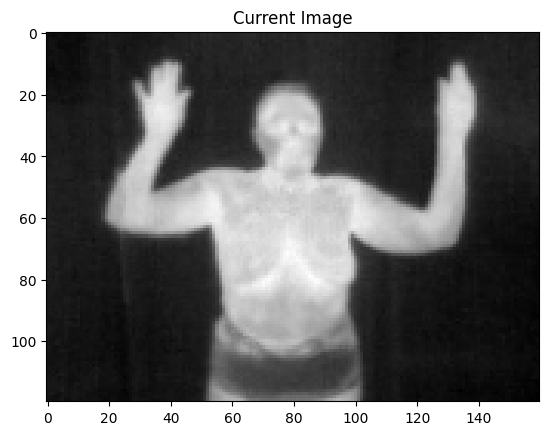

In [ ]:
path_bad_image = ROOT_DIR / 'data/test Flir/test_numpy/IR_21698.npy'
path_good_image = ROOT_DIR / 'data/test Flir/test_numpy/IR_20-09-2018_29576.npy'
random_lines_image = ROOT_DIR / 'data/test Flir/test_numpy/Foto 11-04-2025, 10 01 37.npy'
blurry = ROOT_DIR / 'data/test Flir/test_numpy/IR_13433.npy'

paths_list = os.listdir(output_path)
random_image = random.choice(paths_list)

complete_path = os.path.join(output_path, random_image)
raw_image = np.load(complete_path)
print(raw_image.shape, raw_image.dtype, raw_image.min(), raw_image.max())
plot_grey_image(raw_image)

## Normalization and clipping

In [ ]:
def normalize_image(image):
    image = image.astype(np.float32)
    image = (image - image.min()) / (image.max() - image.min())
    return image

def percentile_clipping_normalize(image, lower_percentile=5, upper_percentile=99):
    p1, p99 = np.percentile(image, [lower_percentile, upper_percentile])
    image = np.clip(image, p1, p99)
    image = (image - p1) / (p99 - p1 + 1e-8)  
    return image 


(120, 160) float32 0.0 0.99999994


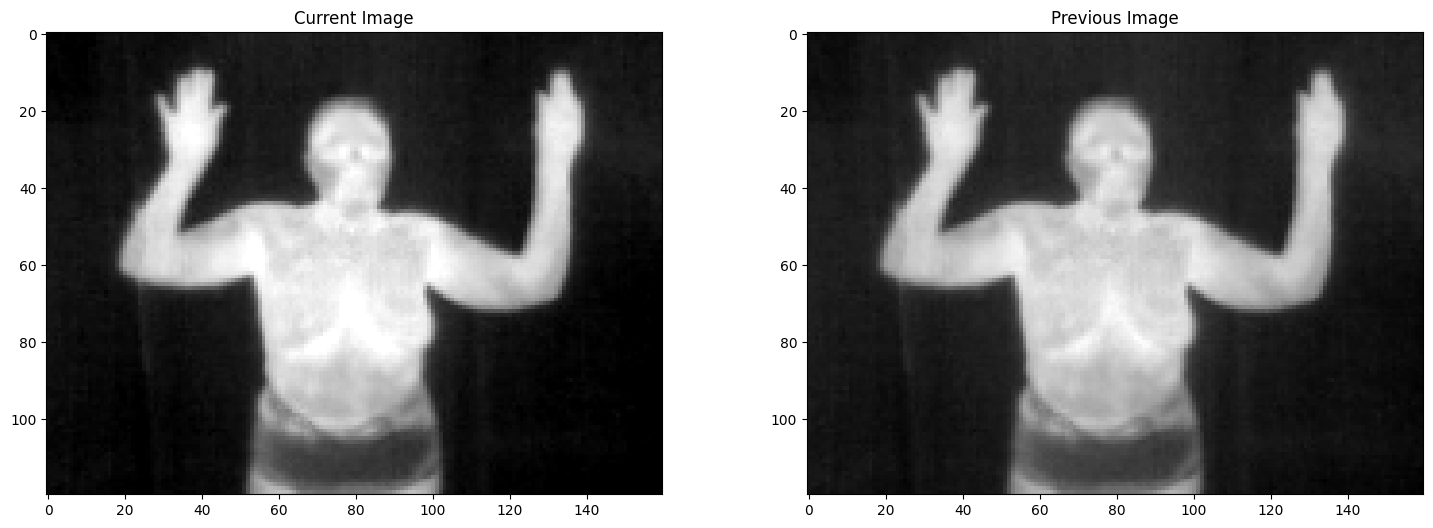

In [ ]:
normalized_image = normalize_image(raw_image)
img_uint8 = percentile_clipping_normalize(normalized_image)
print(img_uint8.shape, img_uint8.dtype, img_uint8.min(), img_uint8.max())
plot_grey_image(img_uint8, raw_image)

## Background Removal

## Remove bad pixels with median filter local

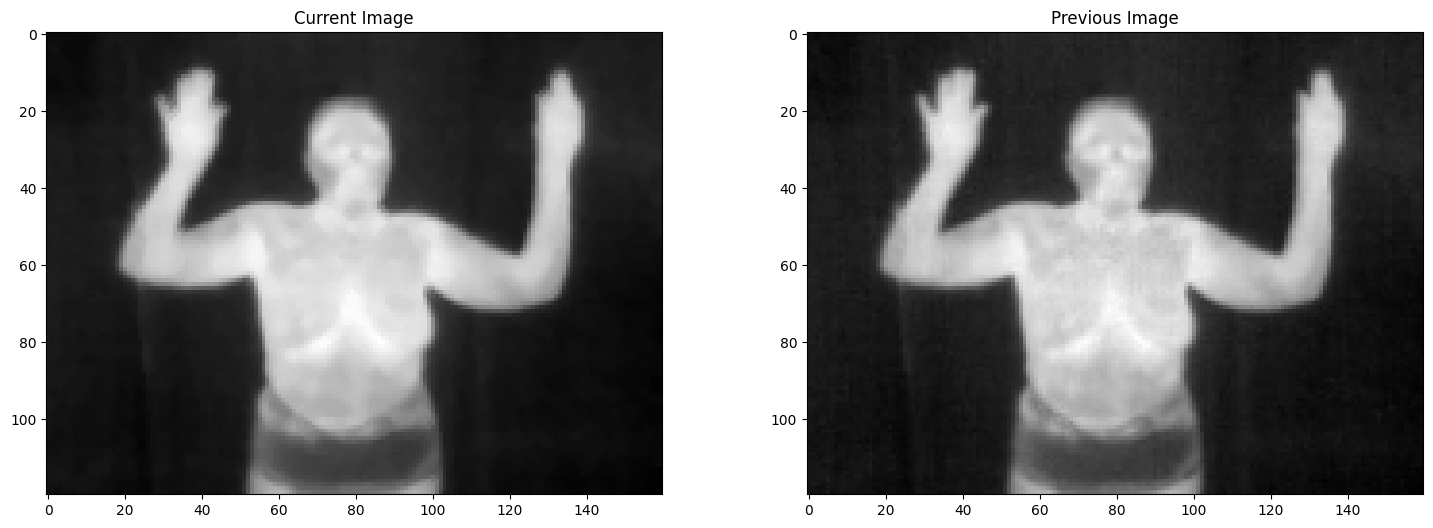

In [ ]:
def remove_bad_pixels(img: np.ndarray, ksize: int = 3) -> np.ndarray:
    return cv2.medianBlur(img.astype(np.float32), ksize)

filtered = remove_bad_pixels(normalized_image, ksize=3)
plot_grey_image(filtered, normalized_image)

## Denoising

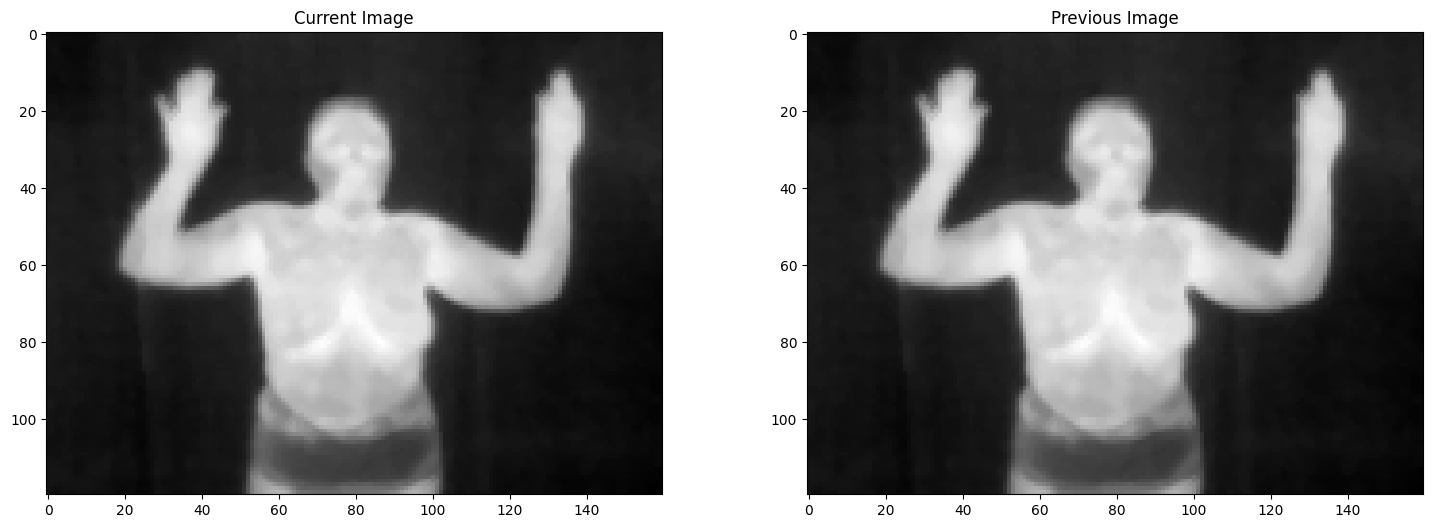

In [ ]:
from skimage.restoration import denoise_wavelet

def denoise_wavelet_light(img: np.ndarray,
                          wavelet: str = 'db1',
                          method: str = 'BayesShrink',
                          mode: str = 'hard',
                          rescale_sigma: bool = True) -> np.ndarray:
    den = denoise_wavelet(img,
                          wavelet=wavelet,
                          method=method,
                          mode=mode,
                          rescale_sigma=rescale_sigma)
    return den.astype(np.float32)
denoised = denoise_wavelet_light(filtered)
plot_grey_image(denoised, filtered)

## CLAHE

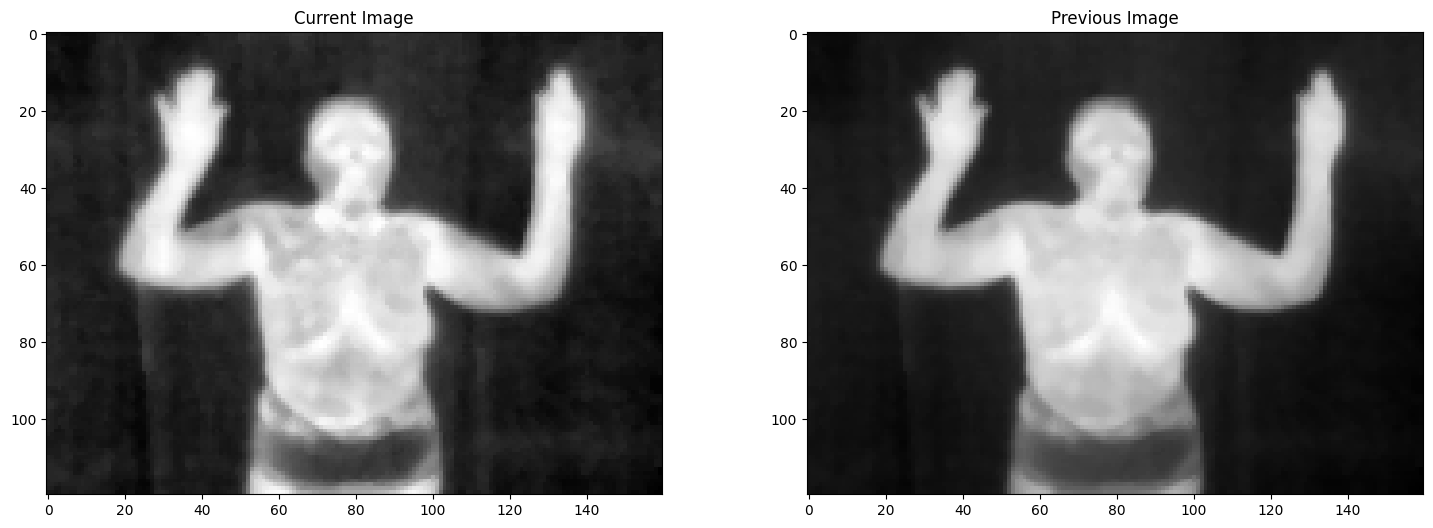

In [ ]:
import cv2
import numpy as np

def apply_clahe(img: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:

    orig_dtype = img.dtype
    if orig_dtype == np.float32 or orig_dtype == np.float64:
        mn, mx = img.min(), img.max()
        img_uint8 = ((img - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
    else:
        img_uint8 = img.copy()

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    out_uint8 = clahe.apply(img_uint8)

    if orig_dtype == np.float32 or orig_dtype == np.float64:
        out = out_uint8.astype(np.float32) / 255.0 * (mx - mn) + mn
    else:
        out = out_uint8
    return out

enhanced = apply_clahe(denoised)
plot_grey_image(enhanced, denoised)

## Sharpening

mask: (120, 160) bool 15360 True patches


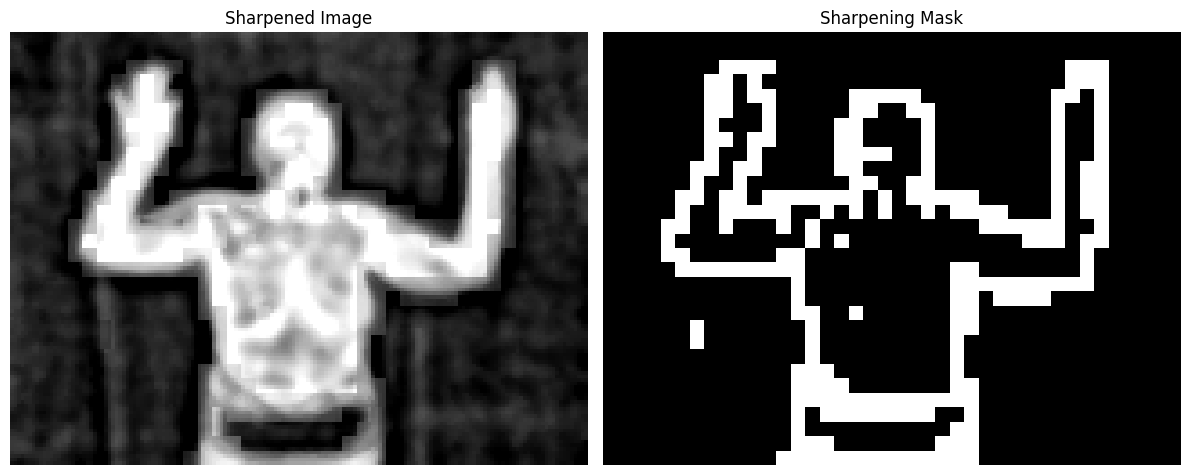

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def patch_blur_mask_adaptive(img: np.ndarray,
                             patch_size: int = 32,
                             percentile: float = 10.0) -> np.ndarray:
    if img.dtype != np.uint8:
        arr = (img * 255).clip(0, 255).astype(np.uint8)
    else:
        arr = img.copy()

    H, W = arr.shape
    vars_, coords = [], []

    for y in range(0, H, patch_size):
        for x in range(0, W, patch_size):
            p = arr[y:y+patch_size, x:x+patch_size]
            v = cv2.Laplacian(p, cv2.CV_64F).var()
            vars_.append(v)
            coords.append((y, x))

    vars_ = np.array(vars_)
    thr = np.percentile(vars_, percentile)

    mask = np.zeros((H, W), dtype=bool)
    for (y, x), v in zip(coords, vars_):
        if v < thr:
            mask[y:y+patch_size, x:x+patch_size] = True

    return mask

def dog_sharpen_patchwise(img: np.ndarray,
                          mask: np.ndarray,
                          k1: int = 5, k2: int = 9,
                          sigma1: float = 0.8, sigma2: float = 2.4,
                          amount: float = 2.0) -> np.ndarray:

    base = (img.astype(np.float32) if img.dtype == np.uint8 else (img * 255.0)).copy()
    g1 = cv2.getGaussianKernel(k1, sigma1)
    g2 = cv2.getGaussianKernel(k2, sigma2)
    G1 = g1 @ g1.T
    G2 = g2 @ g2.T

    blur1 = cv2.filter2D(base, -1, G1)
    blur2 = cv2.filter2D(base, -1, G2)
    dog   = blur1 - blur2

    out = base.copy()
    out[mask] = np.clip(base[mask] + amount * dog[mask], 0, 255)

    if img.dtype != np.uint8:
        out = out / 255.0

    return out.astype(img.dtype)

import numpy as np
import cv2

def global_dog_sharpen(img: np.ndarray,
                       k1: int = 5, sigma1: float = 1.0,
                       k2: int = 9, sigma2: float = 4.0,
                       amount: float = 2.0) -> np.ndarray:

    orig_dtype = img.dtype
    if orig_dtype != np.uint8:
        base = (img.astype(np.float32) * 255.0).copy()
    else:
        base = img.astype(np.float32).copy()

    g1 = cv2.getGaussianKernel(k1, sigma1)
    g2 = cv2.getGaussianKernel(k2, sigma2)
    G1 = g1 @ g1.T
    G2 = g2 @ g2.T

    blur1 = cv2.filter2D(base, -1, G1)
    blur2 = cv2.filter2D(base, -1, G2)
    dog   = blur1 - blur2

    out = base + amount * dog
    out = np.clip(out, 0, 255)

    if orig_dtype != np.uint8:
        out = (out / 255.0).astype(np.float32)
    else:
        out = out.round().astype(np.uint8)
    return out


mask = patch_blur_mask_adaptive(enhanced, patch_size=4, percentile=80.0)
print("mask:", mask.shape, mask.dtype, mask.sum(), "True patches")

sharpened = dog_sharpen_patchwise(enhanced, mask,
                                  k1=7, k2=13,
                                  sigma1=1.5, sigma2=6,
                                  amount=3.0)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(sharpened, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Sharpened Image')
ax[0].axis('off')
ax[1].imshow(mask, cmap='binary', vmin=0, vmax=1)
ax[1].set_title('Sharpening Mask')
ax[1].axis('off')
plt.tight_layout()
plt.show()

sharpened = global_dog_sharpen(enhanced, 
                                 k1=7, k2=13,
                                 sigma1=1.5, sigma2=6,
                                 amount=3.0)

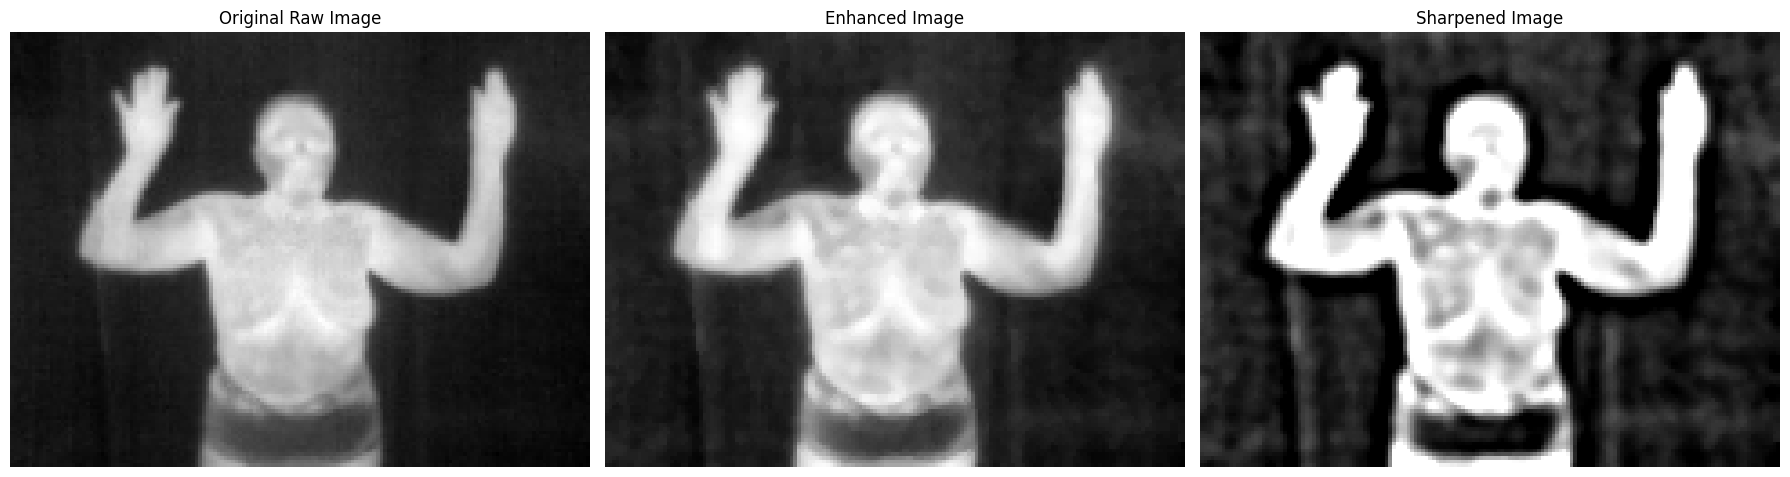

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(raw_image, cmap='gray')
ax[0].set_title('Original Raw Image')
ax[0].axis('off')
ax[1].imshow(enhanced, cmap='gray')
ax[1].set_title('Enhanced Image')
ax[1].axis('off')
ax[2].imshow(sharpened, cmap='gray')
ax[2].set_title('Sharpened Image')
ax[2].axis('off')
plt.tight_layout()
plt.show()